In [40]:
import os, tarfile, random, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import ImageOps
from IPython.display import Image, display

In [41]:
def extract_file():
    print("Extract data...")
    path = "./datasets"
    if not os.path.isdir(path + "/images"):
        print("Unzip Image Data")
        file = tarfile.open("./datasets/images.tar.gz")
        file.extractall(path)
        file.close()
    else:
        print("Folder is exists")

    if not os.path.isdir("./datasets/annotations"):
        print("Annotations data unzip!")
        file = tarfile.open("./datasets/annotations.tar.gz")

        # Extracing file
        file.extractall("./datasets")
        file.close()
    else:
        print("Folder is exists")

In [42]:
extract_file()

Extract data...
Folder is exists
Folder is exists


In [43]:
HEIGHT, WIDTH = 160, 160
NUM_CLASS = 3
BATCH_SIZE = 5
EPOCHS = 10

In [44]:
input_dir = "datasets/images"
mask_dir = "datasets/annotations/trimaps"
img_size = (WIDTH, HEIGHT)

img_src = sorted(
    [
        os.path.join(input_dir, fname)
        for fname in os.listdir(input_dir)
        if fname.endswith(".jpg")
    ]
)

mask_src = sorted(
    [
        os.path.join(mask_dir, fname)
        for fname in os.listdir(mask_dir)
        if fname.endswith(".png") and not fname.startswith(".")
    ]
)

print("Sample Size:")
print("Input: ", len(img_src), " target: ", len(mask_src))
for input_path, mask_path in zip(img_src[:10], mask_src[:10]):
    print(input_path, ":", mask_path)

Sample Size:
Input:  7390  target:  7390
datasets/images\Abyssinian_1.jpg : datasets/annotations/trimaps\Abyssinian_1.png
datasets/images\Abyssinian_10.jpg : datasets/annotations/trimaps\Abyssinian_10.png
datasets/images\Abyssinian_100.jpg : datasets/annotations/trimaps\Abyssinian_100.png
datasets/images\Abyssinian_101.jpg : datasets/annotations/trimaps\Abyssinian_101.png
datasets/images\Abyssinian_102.jpg : datasets/annotations/trimaps\Abyssinian_102.png
datasets/images\Abyssinian_103.jpg : datasets/annotations/trimaps\Abyssinian_103.png
datasets/images\Abyssinian_104.jpg : datasets/annotations/trimaps\Abyssinian_104.png
datasets/images\Abyssinian_105.jpg : datasets/annotations/trimaps\Abyssinian_105.png
datasets/images\Abyssinian_106.jpg : datasets/annotations/trimaps\Abyssinian_106.png
datasets/images\Abyssinian_107.jpg : datasets/annotations/trimaps\Abyssinian_107.png


<Figure size 1000x500 with 0 Axes>

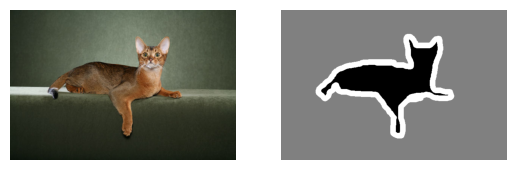

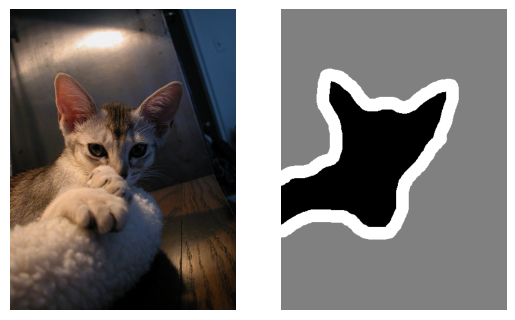

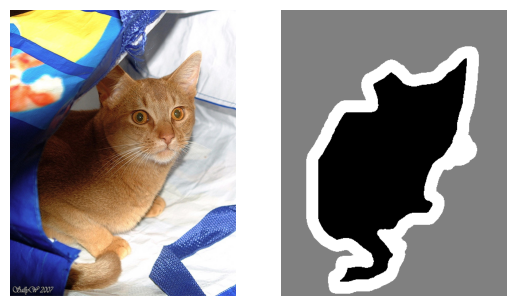

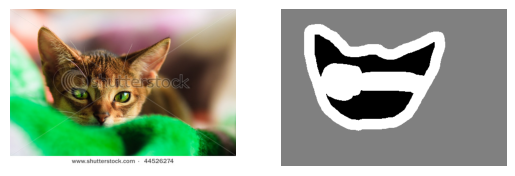

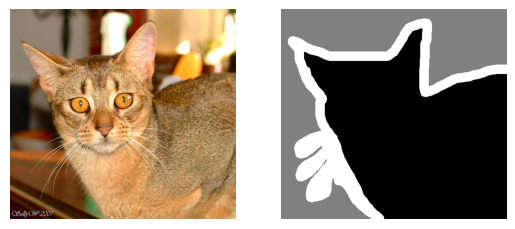

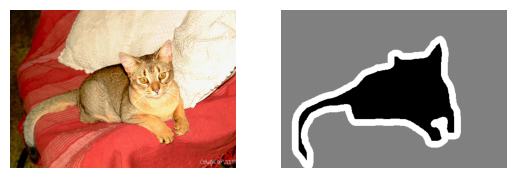

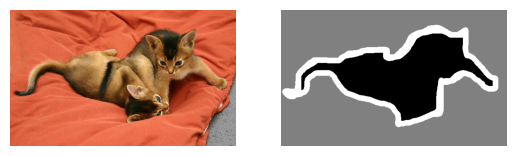

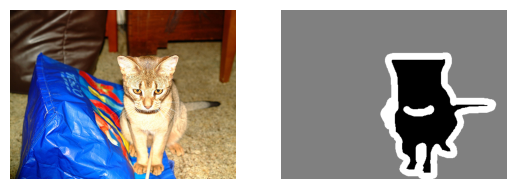

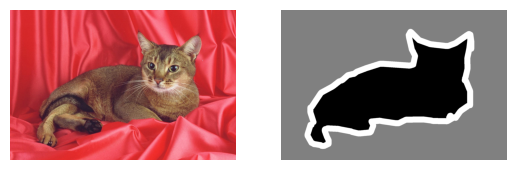

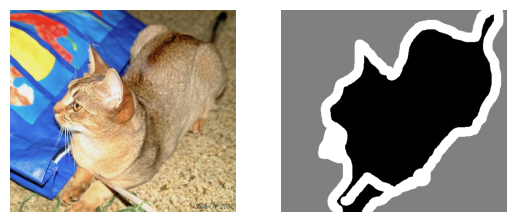

In [45]:
plt.figure(figsize=(10, 5))

for idx in range(10):
    fig, ax = plt.subplots(nrows=1, ncols=2)
    for a in ax.ravel(): a.set_axis_off()

    # img = plt.imread(img_src[idx])

    img = cv2.imread(img_src[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img2 = plt.imread(mask_src[idx])
    
    # img2 = cv2.imread(mask_src[idx], 0)
    # img2 -= 1

    ax[0].imshow(img)
    ax[1].imshow(img2, cmap='gray')

In [46]:
# Convert

def prepare(img_src, mask_src, img_size):
    x = np.zeros(
            (len(img_src), ) + img_size + (3, ),
            dtype=np.float32
    )
    for idx in range(len(img_src)):
        img = tf.keras.preprocessing.image.load_img(img_src[idx], target_size=img_size)
        x[idx] = img
    
    # --------------------------------

    y = np.zeros(
            (len(img_src), ) + img_size + (1, ),
            dtype=np.float32
    )
    for idx in range(len(img_src)):
        img = tf.keras.preprocessing.image.load_img(mask_src[idx], target_size=img_size, color_mode="grayscale")
        y[idx] = np.expand_dims(img, 2)
        # Match label of trimap 1,2,3 to display on IPython 0,1,2 (ลดค่าที่อยู่ข้างในลงอย่างละ 1)
        y[idx] -= 1

    return x, y

In [47]:
def load_data(shuffle=True, st=50, sp=20, ex=10, img_size=(160, 160)):
    if shuffle:
        random.Random(1337).shuffle(img_src)
        random.Random(1337).shuffle(mask_src)
    
    train_image, test_image = img_src[:st], img_src[st:st+sp]
    train_label, test_label = mask_src[:st], mask_src[st:st+sp]

    train_image, train_label = prepare(train_image, train_label, img_size=img_size)
    test_image, test_label = prepare(test_image, test_label, img_size=img_size)

    return (train_image, train_label), (test_image, test_label)

In [48]:
train_set, val_set = load_data()

train_image, train_mask = train_set
val_image, val_mask = val_set

print("Train set: ", train_image.shape, train_mask.shape)
print("Validation set: ", val_image.shape, val_mask.shape)

Train set:  (50, 160, 160, 3) (50, 160, 160, 1)
Validation set:  (20, 160, 160, 3) (20, 160, 160, 1)


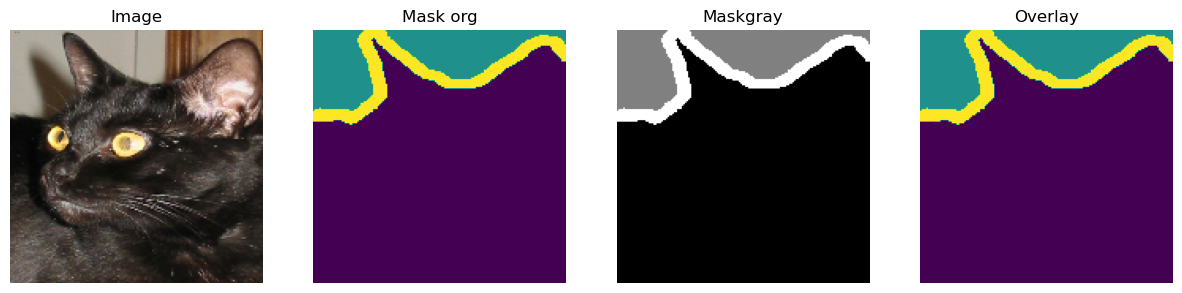

In [99]:
# !ออกสอบ Block นี้

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))

for a in ax.ravel(): a.set_axis_off()

idx = random.randint(1, 50)

title = ["Image", "Mask org", "Maskgray", "Overlay"]
for i in range(len(title)):
    ax[i].set_title(title[i])

ax[0].imshow(train_image[idx].astype(np.uint8))
ax[1].imshow(train_mask[idx])
ax[2].imshow(train_mask[idx], cmap="gray")

# TODO: Make it overlay with cv2.
ax[3].imshow(train_mask[idx])
